# Logistic Regression vs NN on IMDb dataset

In this study, I compare logistic regression and a neural network for binary
sentiment classification on the IMDb movie review dataset. Text data is
represented with TF-IDF features of each text. The goal is to evaluate how well each model separates positive from negative reviews.

In [144]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from torch import nn, tensor, relu
import torch
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import re

torch.manual_seed(52)
np.random.seed(52)


## EDA

### Data inspection

The initial dataset consists of 3 parts: `train`, `test`, `unsupervised`. However, only the supervised splits are used as this work focuses on supervised learning.

In [145]:
dataset = load_dataset("imdb")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Feature `text` is the only input feature in the dataset, which contains a movie review. Feature  `label` is a binary target variable (**0** - negative review, **1** - positive review)

In [146]:
train = dataset['train']
test = dataset['test']
train

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

### Target class imbalance analysis

In this step, a bar chart of target class distribution is illustrated. X axis represents value of a target variable, while Y axis is the amount of each class in the dataset.

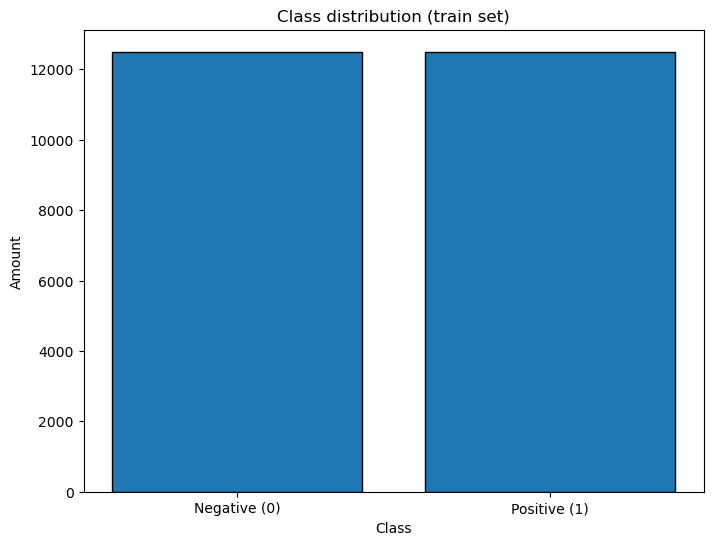

In [147]:
labels = ['Negative (0)', 'Positive (1)']
values = [train['label'].count(0), train['label'].count(1)]

plt.figure(figsize=(8, 6))
plt.bar(labels, values, edgecolor='black')

plt.title('Class distribution (train set)')
plt.xlabel('Class')
plt.ylabel('Amount')

plt.show()

According to target class distribution bar chart, dataset is perfectly balanced, which means accuracy is a valid evaluation metric.

### Word count distribution

This plot shows the distribution of reviews' length. Word count for review is depicted on X axis, amount of reviews is reflected on Y axis.

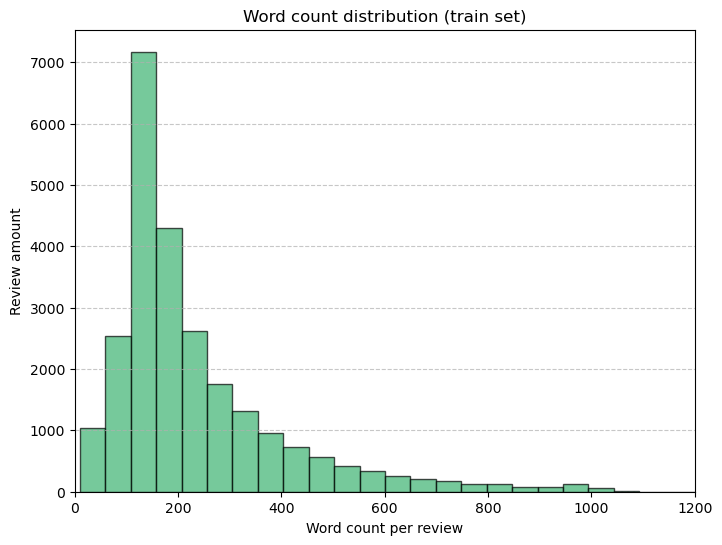

In [148]:
len_texts = list(map(lambda x: len(x['text'].split()), train))

plt.figure(figsize=(8, 6))

plt.hist(len_texts, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)

plt.title('Word count distribution (train set)')
plt.xlabel('Word count per review')
plt.ylabel('Review amount')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 1200)
plt.show()

Based on the plot, the majority of reviews contain less than 200 words.

## Data preprocessing

### Text Preprocessing

Within this step, I prepare text for vectorization. Firstly, text has to be in lowercase, to avoid repeating of same words like **"Apple"** and **"apple"**. 

Then, I remove all `<br />` tags. 

Finally, all punctuation marks are removed. To solve this issue, I applied `re` module and created a Regex pattern **[^a-z\s]**. It ignores all letters and spaces, consequently removing all other symbols.

In [149]:
def clean_dataset_text(row):
    text = row['text'].lower()
    text = text.replace('<br />', '')
    text = re.sub('[^a-z\s]', '', text)
    return {"text": text}

train = train.map(clean_dataset_text)
test = test.map(clean_dataset_text)

### TF-IDF Vectorization

First, I separate the raw texts from their labels for both train and test splits.

TF-IDF (Term Frequency–Inverse Document Frequency) is a weighting scheme that reflects
how important a word is to a document relative to the entire corpus. 

So, I implement TF-IDF algorithm with several certain parameters. 

Firstly, by setting `max_features=30000` I limit the vocabulary to the 30,000 most frequent tokens in order to avoid noise from rare words. 

Then, I set `ngram_range=(1, 2)`, so the TF-IDF algorithm considers both individual words (unigrams) and two-word combinations (bigrams), allowing the model to capture simple phrases like *"not good"* or *"highly recommend"*.

Flag `sublinear_tf=True` applies log-normalization to term frequencies, so it reduces the dominance of very frequent words. 

Parameter `min_df=2` excludes tokens that appear in fewer than 2 documents, removing rare noise, while `max_df=0.95` ignores terms present in more than 95% of documents, filtering out near-universal stopwords.

Finally, the original test set is further split into validation (20%) and test (80%) subsets, with the aim of using val set for hyperparameter tuning and val loss monitoring.

In [150]:
train_texts = [row['text'] for row in train]
y_train = [row['label'] for row in train]
test_texts = [row['text'] for row in test]
y_test = [row['label'] for row in test]

transformer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), sublinear_tf=True, min_df=2, max_df=0.95)
X_train = transformer.fit_transform(train_texts)
X_test = transformer.transform(test_texts)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.8)

## Logistic regression baseline

In [164]:
baseline_model = LogisticRegression()
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.89885
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      9974
           1       0.90      0.90      0.90     10026

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000



Logistic regression shows strong performance due to the high-dimensional and sparse nature of TF-IDF features, which are linearly separable.

## Neural Network implementation

### Custom Dataset

I create custom `IMDbDataset` class to wrap the data for use with PyTorch's DataLoader. I overrode class constructor, `__len__` function, which returns dataset row number, and also `__getitem__` function, which returns certain row and target value by index

In [152]:
class IMDbDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return self.X.shape[0]
        
    def __getitem__(self, idx):
        return self.X[idx], torch.tensor(self.y[idx]).float()

### Data Loader objects creation

I convert train, validation and test sets to float32 tensors. Then, custom `IMDbDataset` objects are created and wrapped into `DataLoader` objects. I applied batch size of 64 and enable shuffling.

In [153]:
X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)

train_dataset = IMDbDataset(X_train_dense, y_train)
val_dataset = IMDbDataset(X_val_dense, y_val)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

### Neural Network architecture

I implemented 256 - 64 - 1 layers architecture as train set includes 25000 examples, such architecture provides moderate learning pace.

I chose `ReLU` activation for inner layers. For output layer I used `Linear` activation, which allows to apply `BCEWithLogitsLoss` loss function, which is more numerically stable than standard Binary Cross Entropy.

`BatchNorm1d` is applied after each linear layer to normalize activations, which stabilizes and accelerates training.

`Dropout` is set **0.6** for first layer and **0.4** for second layer to reduce overfitting.

In [154]:
class IMDbModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.pipeline = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.6),
            
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(64, 1)
        )
    def forward(self, X):
        return self.pipeline(X)

## Training Loop

Hyperparameters were selected empirically based on validation loss monitoring. Chosen architecture lead to the decision of selecting `lr = 1e-5` and `weight_decay = 1e-2` as they provide optimal learning pace. Similarly, number of epochs were limited to 10, as further NN learning didn't contribute to accuracy improvement.

In [158]:
model = IMDbModel(X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-5, weight_decay=1e-2)

epochs = 10

train_loss_hist = []
val_loss_hist = []

for epoch in range(epochs):
    train_batch_loss_hist = []
    val_batch_loss_hist = []
    model.train()

    for batch in train_loader:
        X_batch, y_batch = batch
        optimizer.zero_grad()
        y_batch_pred = model(X_batch)
        batch_loss = criterion(y_batch_pred.squeeze(), y_batch)
        train_batch_loss_hist.append(batch_loss.item())
        batch_loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            X_batch, y_batch = batch
            y_batch_pred = model(X_batch)
            batch_loss = criterion(y_batch_pred.squeeze(), y_batch)
            val_batch_loss_hist.append(batch_loss.item())

    print(f'Epoch {epoch} | Train Loss: {np.mean(train_batch_loss_hist)} | Val Loss: {np.mean(val_batch_loss_hist)}')
    train_loss_hist.append(np.mean(train_batch_loss_hist))
    val_loss_hist.append(np.mean(val_batch_loss_hist))

model.eval()
with torch.no_grad():
    y_test_pred_logits = model(torch.tensor(X_test.toarray(), dtype=torch.float32))

Epoch 0 | Train Loss: 0.6600876282852934 | Val Loss: 0.5714930982529363
Epoch 1 | Train Loss: 0.5301576875664694 | Val Loss: 0.4898611861693708
Epoch 2 | Train Loss: 0.44394888147673645 | Val Loss: 0.4349645938299879
Epoch 3 | Train Loss: 0.3792598652260383 | Val Loss: 0.3937249655210519
Epoch 4 | Train Loss: 0.3315729066310331 | Val Loss: 0.36834618977353545
Epoch 5 | Train Loss: 0.29128735060886957 | Val Loss: 0.3487346161015426
Epoch 6 | Train Loss: 0.26047778628823703 | Val Loss: 0.33000143457062636
Epoch 7 | Train Loss: 0.22954706352232668 | Val Loss: 0.3186211237047292
Epoch 8 | Train Loss: 0.20420390954407888 | Val Loss: 0.3098559430505656
Epoch 9 | Train Loss: 0.18264188051528638 | Val Loss: 0.3012098860514315


## Learning curve plotting

The learning curve shows that val loss consistently decreases within all 10 epochs, which indicates stable learning process despite a small gap between train and val loss.

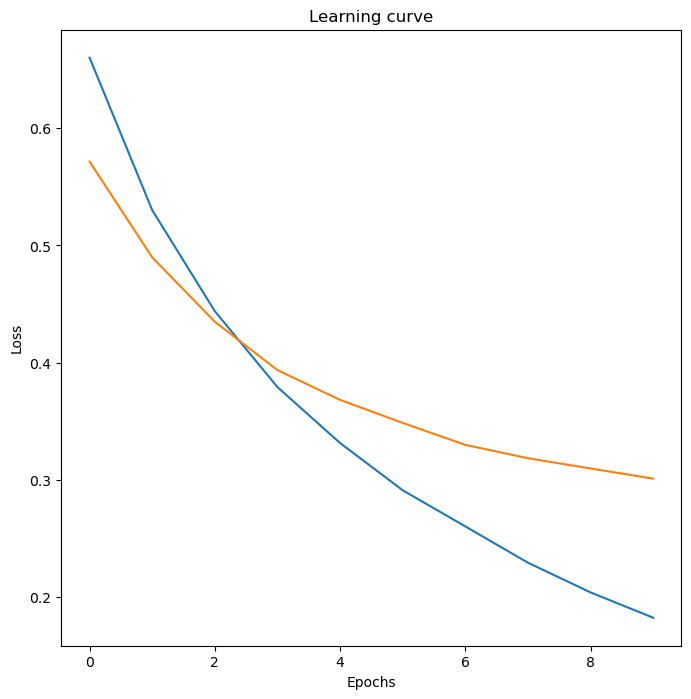

In [162]:
values = [train_loss_hist, val_loss_hist]
plt.figure(figsize=(8, 8))
plt.plot(train_loss_hist, label='Train')
plt.plot(val_loss_hist, label='Val')
plt.title('Learning curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

### Model evaluation

I evaluate final model with accuracy score and `classification_report` in order to compare its performance with Baseline example.

In [163]:
y_pred = (torch.sigmoid(y_test_pred_logits).numpy() > 0.5).astype(int)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9025
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      9974
           1       0.91      0.90      0.90     10026

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000



## Results

This table shows LR and NN performance comparison by accuracy metric.
| Model | Accuracy |
|-------|----------|
| Logistic Regression | 89.89% |
| Neural Network | 90.25% |

Both models achieve similar results as TF-IDF features are already linearly separable, however NN showed a bit better performance due to its nonlinearity. 

### Limitations and future work:
1. Lemmatization - reduces words to their base form. This method would diminish data noise, and potentially increase overall performance and accuracy score
2. Optuna for hyperparameter search – systematically searches hyperparameters in order to find optimal values by accuracy score.
3. Future work could explore sequence-aware architectures such as LSTM or BERT, which capture word order and context unlike feedforward networks